In [ ]:
import h5py
import numpy as np
import mediapy as media
from einops import rearrange
import torch
data = h5py.File("/viscam/projects/dexs2r/libero_init/libero_object_unseen/seed_1023/pick_up_the_red_coffee_mug_and_place_it_in_the_basket.hdf5", "r")

In [ ]:
gt_actions = data['data/demo_35/actions'][:]

In [ ]:
img = data['data/demo_35/obs/agentview_rgb'][:][:,::-1,::-1]
wrist_img = data['data/demo_35/obs/eye_in_hand_rgb'][:][:,::-1, ::-1]
robot0_eef_pos = data['data/demo_35/obs/ee_pos']
robot0_eef_axis = data['data/demo_35/obs/ee_ori']
robot0_gripper_qpos = data['data/demo_35/obs/gripper_states']
task_description = 'open the top drawer and put the bowl inside'


In [ ]:
t = 0

In [ ]:
element = {
                            "observation/image": img[t],
                            "observation/wrist_image": wrist_img[t],
                            "observation/state": np.concatenate(
                                (
                                    robot0_eef_pos[t],
                                    robot0_eef_axis[t]  ,
                                    robot0_gripper_qpos[t],
                                )
                            ),
                            "prompt": str(task_description),
                        }

In [ ]:
def generate_batched_input(element, batch_size, noise_scale=1):
    new_element = element.copy()
    noise = np.random.randn(batch_size, 50, 32) * noise_scale
    for k,v in new_element.items():
        if isinstance(v, str):
            continue
        else:
            new_element[k] = v[None].repeat(batch_size, axis=0)
    payload = {**new_element, "_noise": noise}
    return payload

In [ ]:
from openpi_client import websocket_client_policy as _websocket_client_policy
client = _websocket_client_policy.WebsocketClientPolicy('10.79.12.59', 8000)

In [24]:
action_selector = _websocket_client_policy.WebsocketClientPolicy('0.0.0.0', 9100)

In [ ]:
from action_selection_with_wm import ActionSelectionWithWM

snapshot_dir = "/svl/u/ravenh/lacwm/robot_world_models-raven-lam/projects/latent_action_models/data/experiments_0908/libero_sim_scratch_action_9/2025-11-24/19-41-14/"
action_selector = ActionSelectionWithWM(snapshot_dir=snapshot_dir)

In [ ]:
goal_images = h5py.File('/viscam/projects/dexs2r/libero_init/libero_object_unseen/agentview_goal_images.h5', 'r')['pick_up_the_red_coffee_mug_and_place_it_in_the_basket']

In [ ]:
goal_image = goal_images['0']

In [ ]:
goal_image.shape

In [ ]:
payload = generate_batched_input(element, batch_size=5, noise_scale=1)

In [ ]:
all_action_chunks = np.array(client.infer(payload)["actions"])

In [21]:
obs = {
    "action_chunks": all_action_chunks,
    "agent_obs": img[t],
    "wrist_obs": wrist_img[t],
    "goal_image": goal_image[0],
}

In [25]:
results = action_selector.infer(obs)

In [26]:
all_predictions = results['all_predictions']

In [28]:
for i, prediction in enumerate(all_predictions):
    media.write_video(f"predictions_pi_{i}.mp4", rearrange(prediction, "t c h w -> t h w c") , fps=10)

In [29]:
results['index']

4

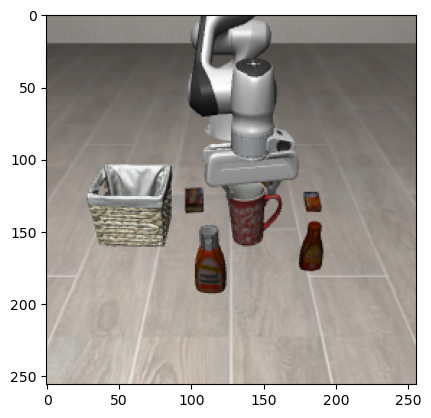

In [30]:
import matplotlib.pyplot as plt
plt.imshow(goal_image[0])
plt.show()